# AG-HYPOPT · Trial 04

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Three trials are registered. **Best = trial_01** (objective 0.1127). Summary of the campaign so far (mu travel = `lr_mu*(1 - mu_anneal/2)`, the total-scale of the mu LR schedule):

- **trial_01 (0.1127, best, 0 diverged):** `lr_mu=0.1551`, `mu_anneal=0.4535`, `lr_gamma=0.7990`, `gamma_anneal=0.2968` (mu travel 0.120). mu rel-RMSE 77.1% (mid-T overshoot 1nW T20 +157%, 3nW T05 +137%; high-T undershoot 3nW T60 -23%, T100 -38%), gamma rel-RMSE 21.5% (accurate at high T, degrading at low T).
- **trial_02 (0.1449, 1 diverged):** `lr_mu=0.2833`, `mu_anneal=0.1501`, `lr_gamma=0.6746`, `gamma_anneal=0.2475` (mu travel 0.264). Larger travel: mu rel-RMSE jumped to 136% (mid-T overshoot up to +275%), plus 1nW T05 gamma diverged (to -2.20).
- **trial_03 (0.1362, 1 diverged):** `lr_mu=0.1076`, `mu_anneal=0.6301`, `lr_gamma=0.9349`, `gamma_anneal=0.5944` (mu travel 0.074). Smaller travel: mu rel-RMSE improved to 55.1% (mid-T overshoot cut to +111% / +91%) but the high-T mu undershoot widened (3nW T100 -41%, T60 -29%, 1nW T100 -19%), and 1nW T05 gamma diverged explosively (2.66e10).

Reading across the three: the objective is minimised at an intermediate mu travel (trial_01), mu *accuracy* is best at the smallest travel (trial_03, 55%) while the objective there is dragged up by the high-T undershoot and by the 1nW T05 gamma divergence. The 1nW T05 gamma cell (smallest n_target) has now diverged in trials 02 and 03 and stayed finite only in trial_01. Cell 2 still reports `phase = uniform` (3/5 trials): no expected-improvement values yet. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_04'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (3/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.8487504950151309, "lr_gamma": 0.5357611751736435, "lr_mu": 0.48824063432531356, "mu_anneal": 0.08083602389560218}
 2 |      - | {"gamma_anneal": 0.5466202487955267, "lr_gamma": 0.4076622551584089, "lr_mu": 0.40194109745797457, "mu_anneal": 0.17452781614402846}
 3 |      - | {"gamma_anneal": 0.7844717467688908, "lr_gamma": 0.5667443307253233, "lr_mu": 0.45159646445941426, "mu_anneal": 0.4771535238392063}
 4 |      - | {"gamma_anneal": 0.3874466499564718, "lr_gamma": 0.799499381667113, "lr_mu": 0.4921557349659051, "mu_anneal": 0.3697257926524288}
 5 |      - | {"gamma_anneal": 0.8720395823846114, "lr_gamma": 0.9325750683771485, "lr_mu": 0.09295782995218065, "mu_anneal": 0.6088516168445476}
 6 |      - | {"gamma_anneal": 0.6343782710082683, "lr_gamma": 0.9456634951727089, "lr_mu": 0.3345004213980479, "mu_anneal": 0.13339575545169313}
 7 |      - | {"gamma_anneal": 0.44808083890683703, "lr_gamma": 0.5189388

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Three data points, no expected-improvement values yet (`phase = uniform`, 3/5). The clearest structure is: mu travel controls a **trade** — larger travel blows up the mid-T mu overshoot (trial_02), smaller travel cuts that overshoot and gives the best mu accuracy but deepens the high-T mu undershoot (trial_03) — and a **second, independent problem**: the 1nW T05 gamma divergence that appeared in both trial_02 and trial_03 but not trial_01.

Trial_03 is the most interesting result: its mu rel-RMSE (55%) is markedly better than trial_01's (77%), so its small-travel mu schedule is genuinely good; the objective is dragged up by the single diverged gamma cell (capped at 1.0) and by the high-T undershoot. The sharpest question for the next trial is therefore whether the 1nW T05 gamma blow-up can be removed while keeping a small mu travel — i.e. keep trial_03's mu regime and *damp* the gamma step, which was the most aggressive of the three in trial_03 (`lr_gamma=0.935`).

Effective mu travel `lr_mu*(1 - mu_anneal/2)` for the candidates, with the gamma step they pair it with:
- candidate 9: `lr_mu=0.138`, `mu_anneal=0.930` -> travel **0.074** (matches trial_03's small-travel regime), with `lr_gamma=0.603` (much lower than trial_03's 0.935) and `gamma_anneal=0.845` (strong decay) — the whole gamma schedule damped relative to trial_03.
- candidate 7: `lr_mu=0.253`, `mu_anneal=0.959` -> travel 0.132 (near trial_01), with `lr_gamma=0.519`, `gamma_anneal=0.448`.
- candidate 8: `lr_mu=0.263`, `mu_anneal=0.641` -> travel 0.178 (between trial_01 and trial_02), `lr_gamma=0.263`.
- candidate 5: `lr_mu=0.093`, `mu_anneal=0.609` -> travel 0.065, but `lr_gamma=0.933`, `gamma_anneal=0.872` (gamma step still large at the start, like trial_03).
- candidates 1/2/3/4/6/10: travel >= 0.20 (the trial_02 direction).

Candidate 9 is the one that keeps the small-travel mu regime that produced the best mu accuracy (trial_03) while damping both gamma knobs (lower `lr_gamma` and higher `gamma_anneal`) relative to trial_03 — a coherent single direction aimed at the one cell that keeps breaking. Candidate 7 keeps mu near trial_01 but changes less about the gamma problem; candidate 5 keeps trial_03's large initial gamma step, which is the prime suspect. So candidate 9 is the most informative next point.

I choose candidate 9 (9 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 9            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.8451963480816079, 'lr_gamma': 0.6029150106146935, 'lr_mu': 0.1375775281943363, 'mu_anneal': 0.9297746953080669}
Running  1nW Trans05 ... 

μ 9.39 -> 9.34 | γ 8.5 -> -52521111462253248.00 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 35.99 | γ 8.5 -> 6.09 | NLL 4.94


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 70.37 | γ 14.1 -> 14.31 | NLL 3.16


Running 3nW Trans100 ... 

μ 175.71 -> 101.26 | γ 14.1 -> 14.02 | NLL 3.18



Total: 7.4 min


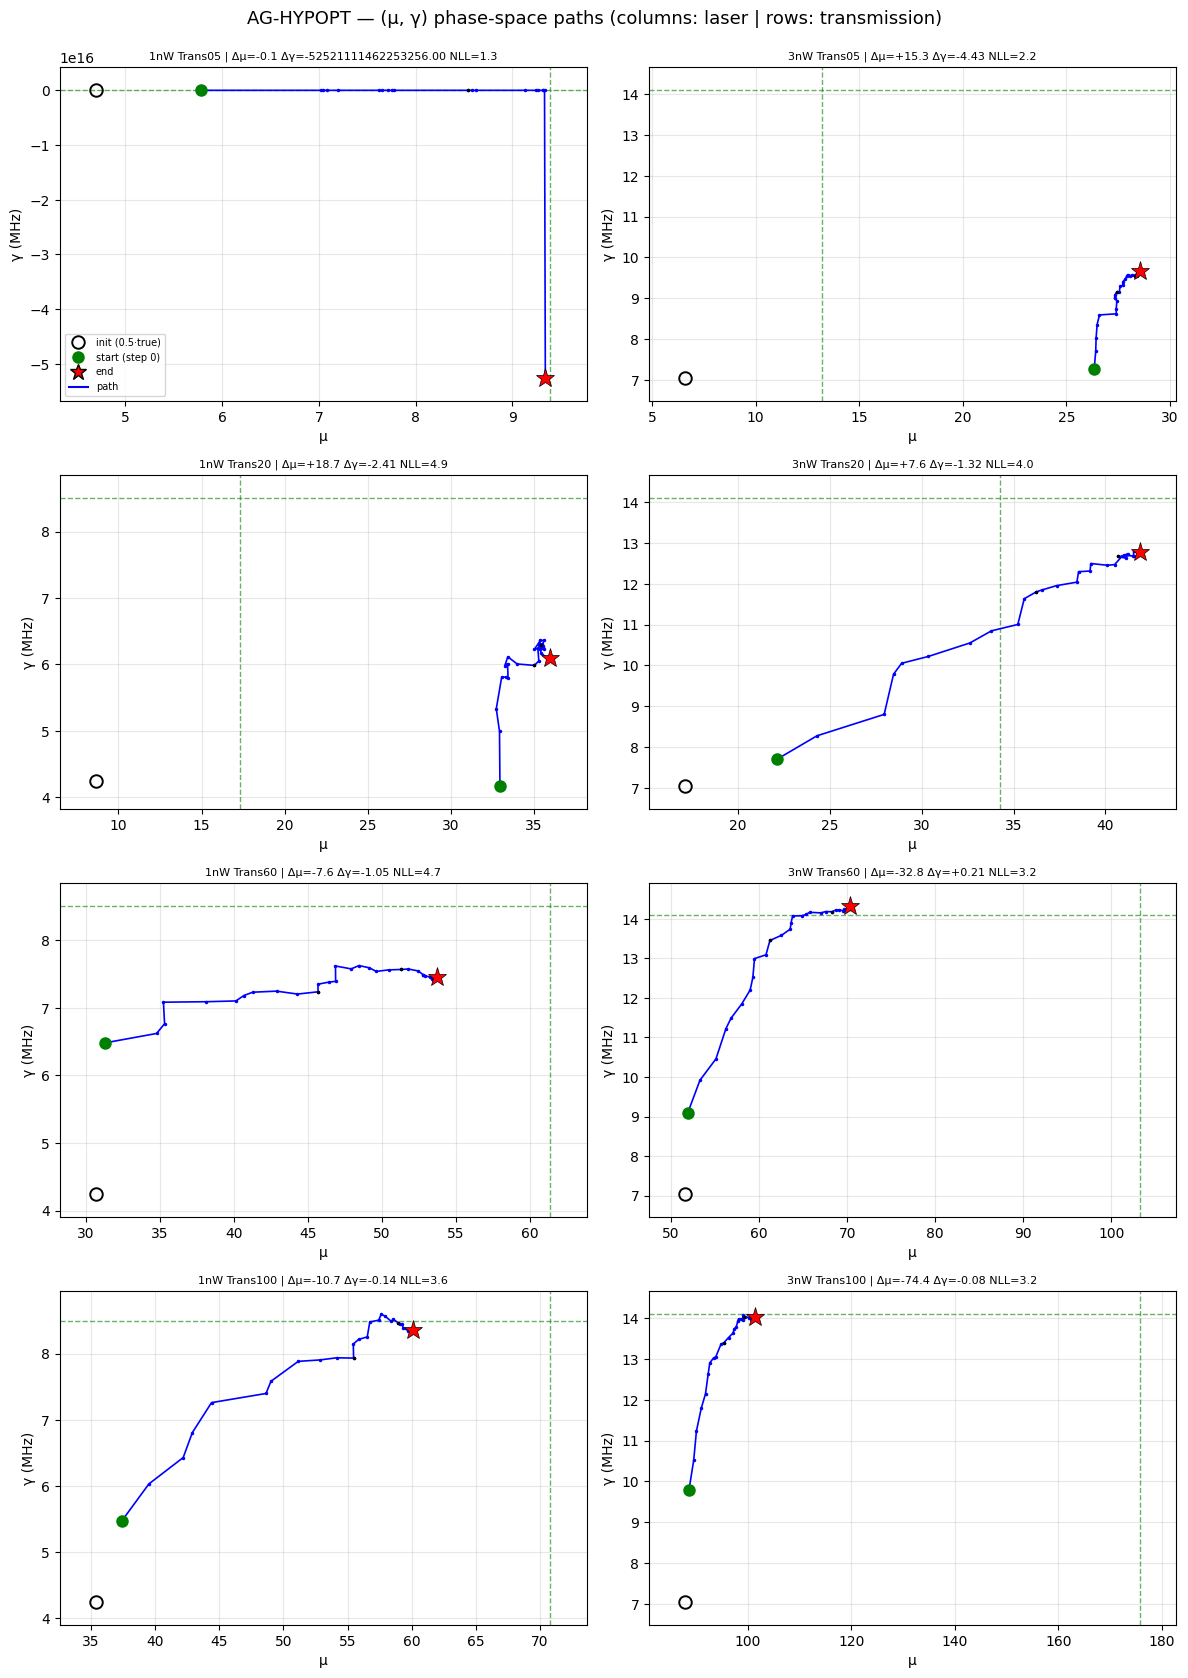

trial finished in 7.5 min
objective = 0.1418 ± 0.0971
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05 !D     9.39    9.34    -0.6 |     8.50-52521111462253248.00-617895428967685376.0
1nW Trans20       17.32   35.99  +107.9 |     8.50    6.09   -28.3
1nW Trans60       61.37   53.73   -12.5 |     8.50    7.45   -12.3
1nW Trans100       70.82   60.11   -15.1 |     8.50    8.36    -1.6
3nW Trans05       13.20   28.53  +116.0 |    14.10    9.67   -31.4
3nW Trans20       34.28   41.86   +22.1 |    14.10   12.78    -9.4
3nW Trans60      103.20   70.37   -31.8 |    14.10   14.31    +1.5
3nW Trans100      175.71  101.26   -42.4 |    14.10   14.02    -0.5

weighted objective (T-graded, cap=1.0) = 0.1418 | diverged cells: 1
μ: RMSE 30.484 (rel 60.0%, bias -10.513) | γ: RMSE 18569017035206892.000 (rel 218459023943610528.0%, bias -6565138932781658.000)


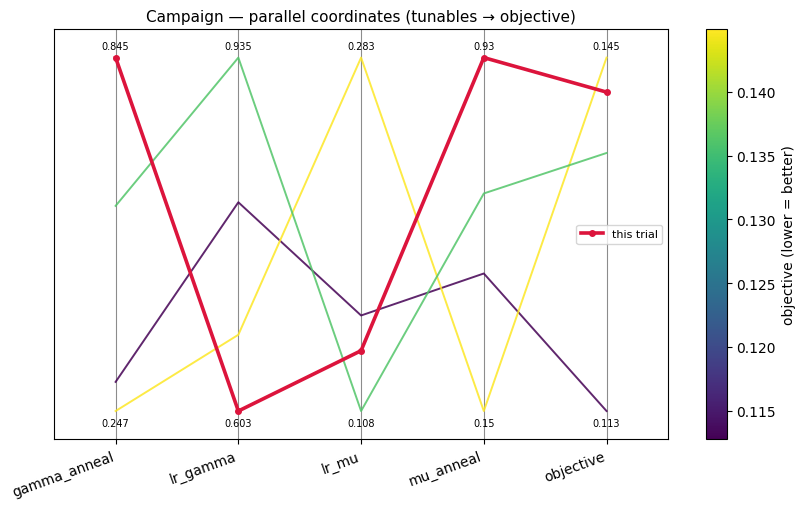

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 04 ran candidate 9: `lr_mu=0.1376`, `mu_anneal=0.9298` (effective mu travel 0.074, matching trial_03), `lr_gamma=0.6029`, `gamma_anneal=0.8452` (both gamma knobs damped relative to trial_03's 0.935 / 0.594). It completed in 7.5 min with objective **0.1418 +/- 0.0971** and **1 diverged cell** (1nW T05: gamma exploded to -5.25e16). Ranking so far: trial_01 0.1127 < trial_03 0.1362 < **trial_04 0.1418** < trial_02 0.1449.

Aggregate accuracy: **mu rel-RMSE 60.0%** (RMSE 30.48, bias -10.51) — close to trial_03's 55.1% and much better than trial_01's 77.1%, so the small-travel mu regime again recovered mu well. Excluding the diverged cell, gamma stays accurate at high T (1nW T100 -1.6%, 3nW T100 -0.5%, 3nW T60 +1.5%) and degrades at low T (3nW T05 -31.4%, 1nW T20 -28.3%).

Per-cell relative errors (1nW T05 gamma is the diverged value; mu there was fine at -0.6%):
- **mu:** 1nW T05 -0.6% (diverged on gamma), T20 +107.9%, T60 -12.5%, T100 -15.1% | 3nW T05 +116.0%, T20 +22.1%, T60 -31.8%, T100 -42.4%.
- **gamma:** 1nW T05 diverged, T20 -28.3%, T60 -12.3%, T100 -1.6% | 3nW T05 -31.4%, T20 -9.4%, T60 +1.5%, T100 -0.5%.

The intended change was to keep trial_03's small-travel mu regime but damp the gamma step (lower `lr_gamma`, higher `gamma_anneal`) to kill the 1nW T05 gamma blow-up. **It did not work:** the same cell diverged again, just as explosively, so the divergence is *not* a gamma-step-size problem. The damped gamma step also slightly hurt where gamma previously succeeded (1nW T60 -8.3% -> -12.3%; 3nW T05 -32.5% -> -31.4% is flat; 1nW T100 -0.8% -> -1.6%), which is why the objective came out a touch above trial_03. mu behaviour was essentially trial_03 repeated (small travel, good mu accuracy, high-T undershoot).

**Summary:** Trial 04 (lr_mu=0.1376, mu_anneal=0.9298, lr_gamma=0.6029, gamma_anneal=0.8452): objective 0.1418 +/- 0.0971, 1 diverged cell (1nW T05, gamma -5.3e16); damping the gamma step did not remove the low-T gamma divergence (now in 3 of 4 trials) and slightly worsened high-T gamma, while the small-travel mu regime again gave good mu accuracy (rel-RMSE 60%).
**Key insight:** The 1nW T05 gamma blow-up is not a gamma-learning-rate problem: it persisted with `lr_gamma` cut to 0.60 and `gamma_anneal` raised to 0.85, so the only trial that avoided it (trial_01) does so through its mu schedule, not its gamma schedule.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Across trials 02-04 the 1nW T05 gamma cell diverges regardless of the gamma schedule, while mu at that same cell converges near truth (-0.6% to -22.5%); the only common factor of the surviving run (trial_01) is a *moderate* mu travel, not any gamma setting. This points at an interaction between the mu trajectory and the (very small n_target) gamma gradient at T05 rather than a simple gamma-step issue. The per-experiment gamma LR / n_target-adaptive step idea (recorded in trials 01-03) is the natural structural fix; here it is only noted, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 04 (lr_mu=0.1376, mu_anneal=0.9298, lr_gamma=0.6029, gamma_anneal=0.8452): objective 0.1418 +/- 0.0971, 1 diverged cell (1nW T05, gamma -5.3e16); damping the gamma step did not remove the low-T gamma divergence (now in 3 of 4 trials) and slightly worsened high-T gamma, while the small-travel mu regime again gave good mu accuracy (rel-RMSE 60%)"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The 1nW T05 gamma blow-up is not a gamma-learning-rate problem: it persisted with lr_gamma cut to 0.60 and gamma_anneal raised to 0.85, so the only trial that avoided it (trial_01) does so through its mu schedule, not its gamma schedule"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_04 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_05.ipynb. Open it and follow its cells from the top.
